# Energy Sentinel — Exploratory Data Analysis

This notebook explores the UK-DALE House 1 dataset.  
Goals:
- Understand the structure and shape of raw channel data
- Inspect timestamps, power readings, and data coverage
- Identify missing data, gaps, and anomalies in raw readings
- Inform preprocessing and feature engineering decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.settings import settings
from src.data.loader import UKDALELoader
from src.utils.logger import get_logger

logger = get_logger("eda")

print("Imports successful")
print(f"Raw data directory: {settings.RAW_DIR}")

Imports successful
Raw data directory: D:\Github\energy-sentinel\data\raw


# 1 - Load Raw Channel Data

In [2]:
loader = UKDALELoader()
data = loader.load_all()

for appliance, df in data.items():
    print(f"{appliance:20s} → {len(df):>10,} records | {df['timestamp'].min()} → {df['timestamp'].max()}")

2026-07-12 04:28:31 | INFO     | src.data.loader | Loading all channels from: D:\Github\energy-sentinel\data\raw\house_1
2026-07-12 04:28:31 | INFO     | src.data.loader | All required channel files found.
2026-07-12 04:30:25 | INFO     | src.data.loader | Loaded channel_1 (Aggregate): 21,837,636 records
2026-07-12 04:31:58 | INFO     | src.data.loader | Loaded channel_5 (Washing Machine): 19,555,935 records
2026-07-12 04:33:29 | INFO     | src.data.loader | Loaded channel_6 (Dishwasher): 19,819,392 records
2026-07-12 04:35:04 | INFO     | src.data.loader | Loaded channel_7 (TV): 19,763,329 records
2026-07-12 04:36:30 | INFO     | src.data.loader | Loaded channel_10 (Kettle): 18,881,051 records
2026-07-12 04:38:11 | INFO     | src.data.loader | Loaded channel_12 (Fridge): 19,381,298 records
2026-07-12 04:39:40 | INFO     | src.data.loader | Loaded channel_13 (Microwave): 19,406,625 records
2026-07-12 04:39:40 | INFO     | src.data.loader | Successfully loaded 7 channels.
Aggregate     

# 2 - Slice & Resample for EDA (2013, 1-minute intervals)

In [3]:
# Define date range — 1 full year
START_DATE = "2013-01-01"
END_DATE   = "2013-12-31"

# Store resampled data for each appliance
resampled = {}

for appliance, df in data.items():
    # Set timestamp as index
    df_indexed = df.set_index("timestamp")
    
    # Filter to 1 year
    df_filtered = df_indexed[START_DATE:END_DATE]
    
    # Resample to 1-minute intervals, take mean power
    df_resampled = df_filtered["power"].resample("1min").mean()
    
    # Store
    resampled[appliance] = df_resampled

    print(f"{appliance:20s} → {len(df_resampled):>10,} records after resample")

Aggregate            →    525,600 records after resample
Washing Machine      →    525,600 records after resample
Dishwasher           →    525,600 records after resample
TV                   →    525,600 records after resample
Kettle               →    525,600 records after resample
Fridge               →    525,600 records after resample
Microwave            →    525,600 records after resample


# 3 - Combine All Appliances into One DataFrame

In [4]:
# Combine all resampled appliances into one DataFrame
df_combined = pd.DataFrame(resampled)

# Check shape and first few rows
print(f"Shape: {df_combined.shape}")
print(f"\nColumns: {list(df_combined.columns)}")
print(f"\nFirst 3 rows:")
df_combined.head(3)

Shape: (525600, 7)

Columns: ['Aggregate', 'Washing Machine', 'Dishwasher', 'TV', 'Kettle', 'Fridge', 'Microwave']

First 3 rows:


,Aggregate,Washing Machine,Dishwasher,TV,Kettle,Fridge,Microwave
timestamp,,,,,,,
2013-01-01 00:00:00+00:00,507.799988,0.0,1.0,94.000000,1.0,88.800003,1.0
2013-01-01 00:01:00+00:00,525.099976,0.0,1.0,108.099998,1.0,88.599998,1.0
2013-01-01 00:02:00+00:00,519.500000,0.0,1.0,101.555557,1.0,88.599998,1.0


# 4 - Basic Info & Missing Values

In [5]:
# Basic info
print(f"Date range : {df_combined.index.min()} → {df_combined.index.max()}")
print(f"Shape      : {df_combined.shape}")
print(f"Total rows : {len(df_combined):,}")

# Missing values
print("\nMissing values per appliance:")
missing = df_combined.isnull().sum()
missing_pct = (df_combined.isnull().sum() / len(df_combined) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
print(missing_df)

Date range : 2013-01-01 00:00:00+00:00 → 2013-12-31 23:59:00+00:00
Shape      : (525600, 7)
Total rows : 525,600

Missing values per appliance:
                 Missing Count  Missing %
Aggregate                34411       6.55
Washing Machine          39567       7.53
Dishwasher               26777       5.09
TV                       27046       5.15
Kettle                   34036       6.48
Fridge                   27545       5.24
Microwave                26791       5.10


# 5 - Power Consumption Summary Statistics

In [6]:
# Summary statistics
print("Power consumption summary (Watts):\n")
print(df_combined.describe().round(2))

Power consumption summary (Watts):

       Aggregate  Washing Machine  Dishwasher         TV     Kettle  \
count  491189.00        486033.00   498823.00  498554.00  491564.00   
mean      357.69            25.22       16.47      11.01      14.43   
std       402.41           185.02      176.45      30.96     159.18   
min        76.60             0.00        0.00       0.00       0.00   
25%       182.25             0.00        1.00       1.00       1.00   
50%       237.40             0.00        1.00       1.00       1.00   
75%       377.00             0.00        1.00       1.00       1.00   
max      6138.33          2246.33     2550.75     301.20    2448.33   

          Fridge  Microwave  
count  498055.00  498809.00  
mean       38.98       5.87  
std        49.06      69.67  
min         0.00       0.00  
25%         0.00       1.00  
50%         0.00       1.00  
75%        87.00       1.00  
max       882.00    1740.89  


# 6 - Daily Energy Consumption Trends

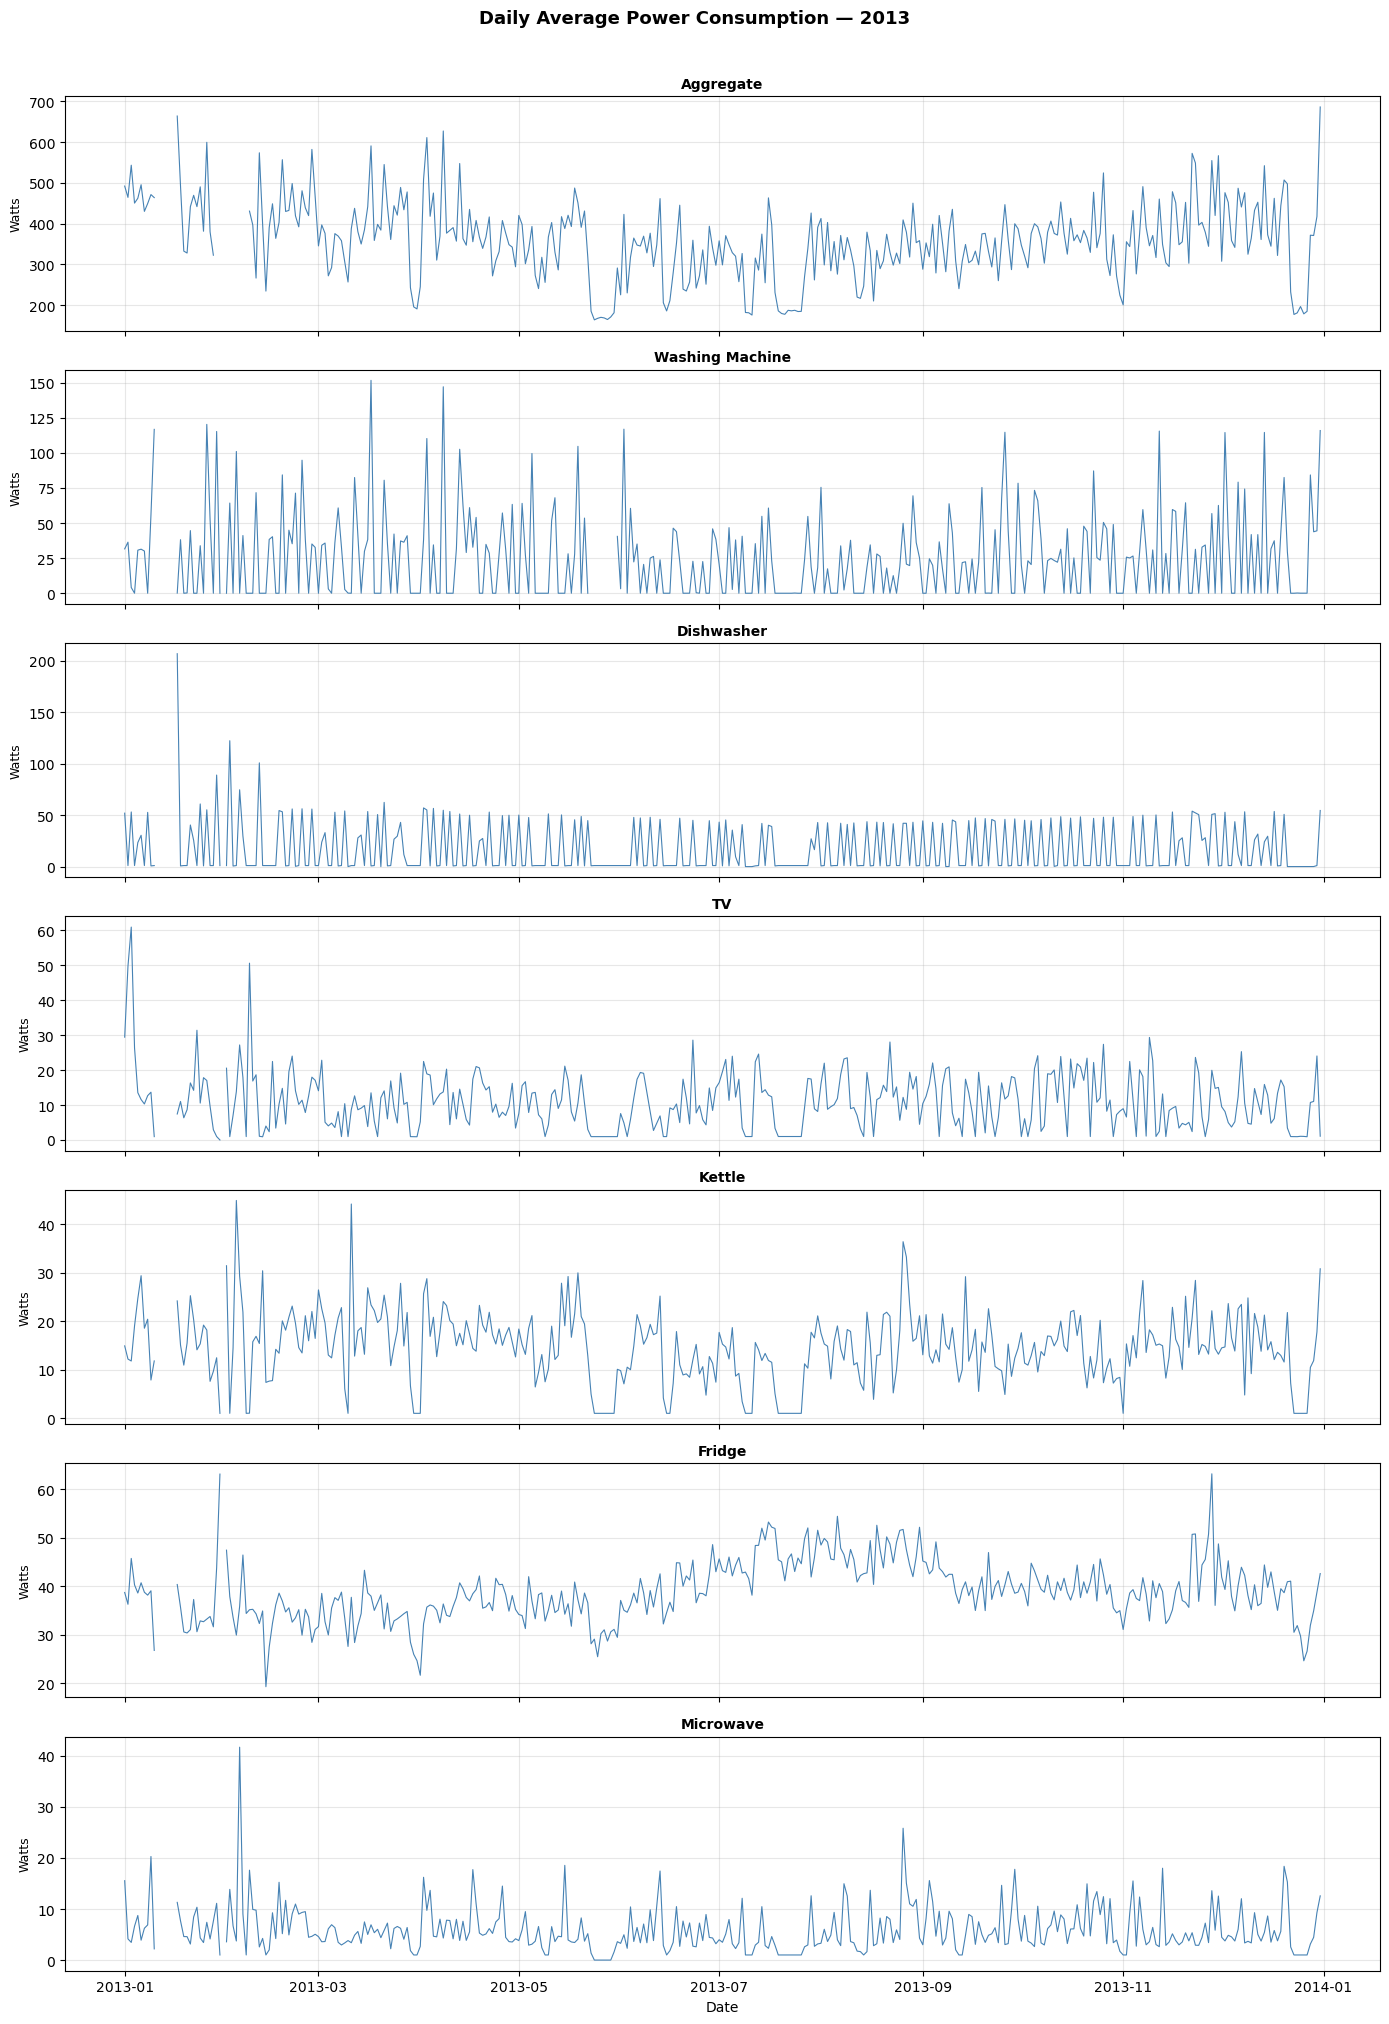

In [7]:
# Calculate daily mean power for each appliance
daily = df_combined.resample("D").mean()

# Plot
fig, axes = plt.subplots(7, 1, figsize=(14, 20), sharex=True)

appliances = df_combined.columns.tolist()

for i, appliance in enumerate(appliances):
    axes[i].plot(daily.index, daily[appliance], linewidth=0.8, color="steelblue")
    axes[i].set_ylabel("Watts", fontsize=9)
    axes[i].set_title(appliance, fontsize=10, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=10)
fig.suptitle("Daily Average Power Consumption — 2013", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 7 - Observations from Daily Trends

In [8]:
# Monthly average — seasonal pattern dekhne ke liye
monthly = df_combined.resample("ME").mean()

print("Monthly Average Power Consumption (Watts):\n")
print(monthly.round(2).to_string())

Monthly Average Power Consumption (Watts):

                            Aggregate  Washing Machine  Dishwasher     TV     Kettle     Fridge  Microwave
timestamp                                                                                                 
2013-01-31 00:00:00+00:00  454.000000        30.559999   24.570000  18.17  16.440001  36.060001       7.16
2013-02-28 00:00:00+00:00  435.940002        30.980000   20.770000  13.13  16.740000  34.099998       8.17
2013-03-31 00:00:00+00:00  378.890015        26.990000   17.020000   8.28  17.450001  34.000000       4.73
2013-04-30 00:00:00+00:00  389.880005        31.660000   20.010000  12.23  17.860001  36.419998       7.13
2013-05-31 00:00:00+00:00  312.100006        24.500000   11.580000   7.88  12.480000  34.070000       3.76
2013-06-30 00:00:00+00:00  310.869995        19.240000   11.570000   9.56  11.850000  39.040001       5.52
2013-07-31 00:00:00+00:00  278.149994        14.130000   12.820000   9.78   8.690000  46.110001     

# 8 - Hourly Usage Patterns (Average by Hour of Day)

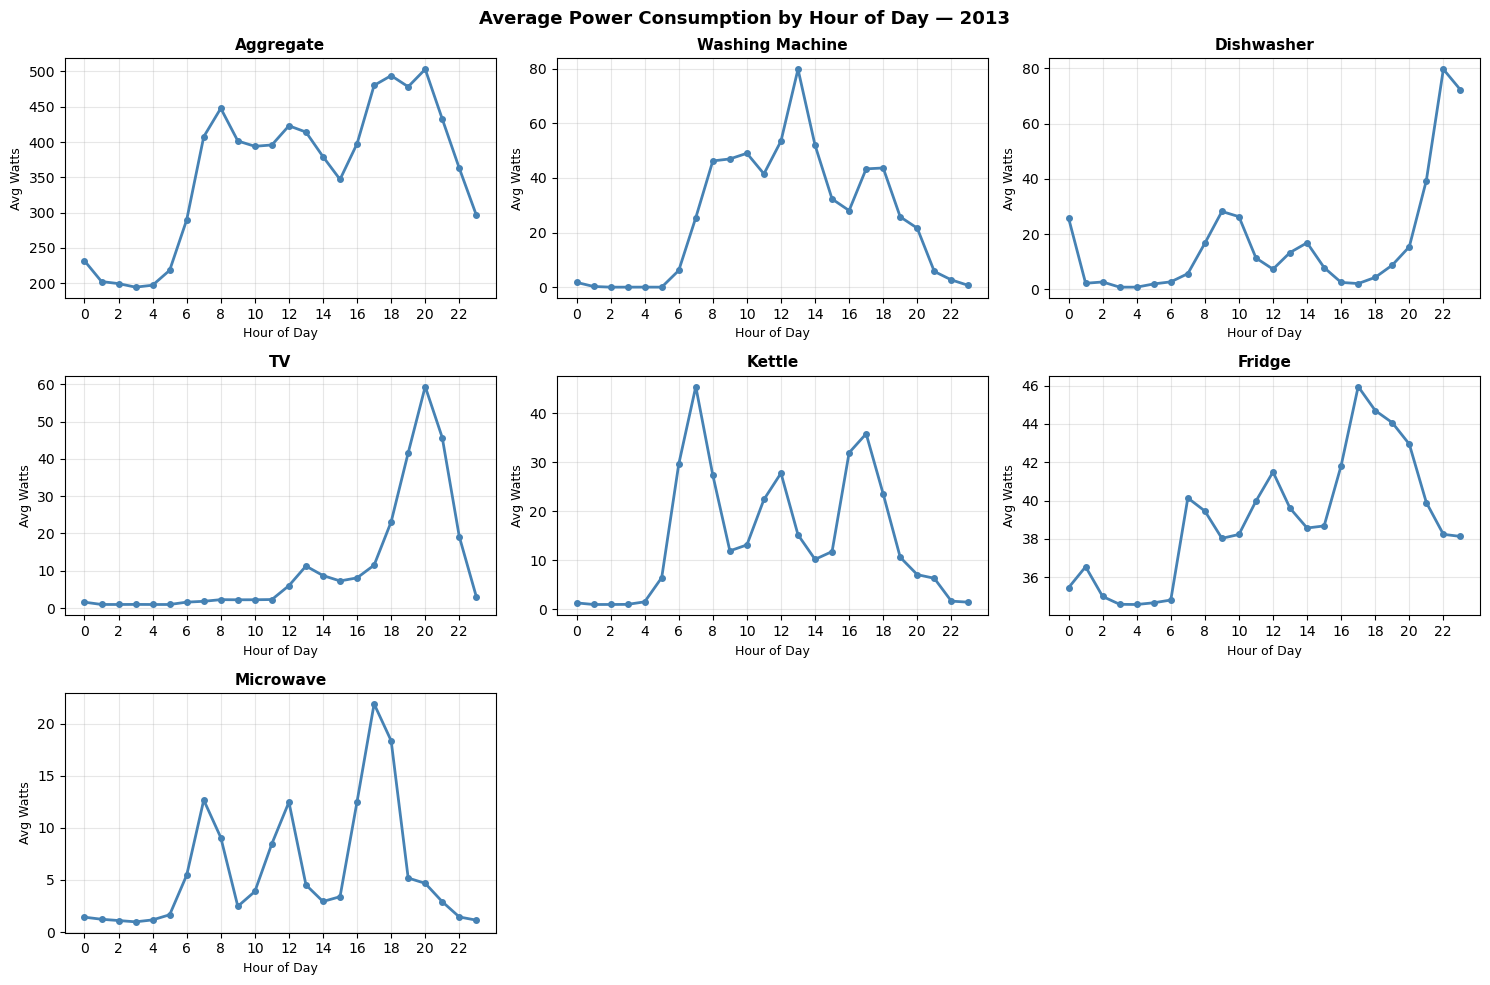

In [9]:
# Hour of day extract karo
df_hourly = df_combined.copy()
df_hourly["hour"] = df_combined.index.hour

# Har appliance ka hourly average
hourly_avg = df_hourly.groupby("hour").mean()

# Plot
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

appliances = df_combined.columns.tolist()

for i, appliance in enumerate(appliances):
    axes[i].plot(hourly_avg.index, hourly_avg[appliance], 
                 marker="o", linewidth=2, markersize=4, color="steelblue")
    axes[i].set_title(appliance, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Hour of Day", fontsize=9)
    axes[i].set_ylabel("Avg Watts", fontsize=9)
    axes[i].set_xticks(range(0, 24, 2))
    axes[i].grid(True, alpha=0.3)

# Extra subplot hide karo (7 appliances hain, 9 subplots hain)
for j in range(len(appliances), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Average Power Consumption by Hour of Day — 2013", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 9 - Weekday vs Weekend Consumption Patterns

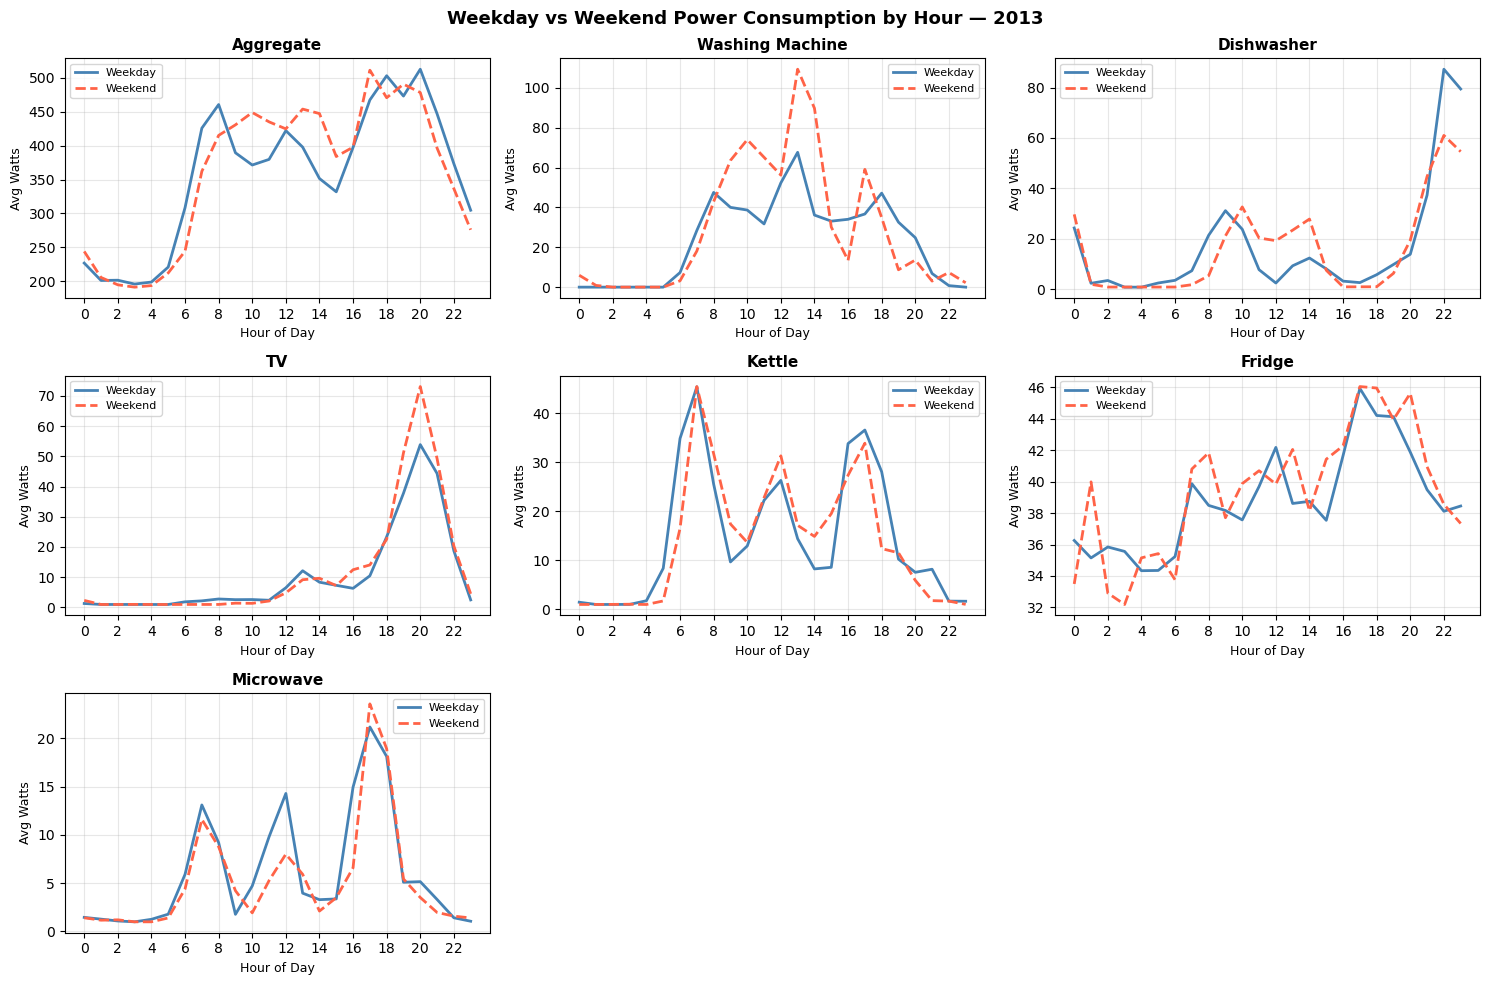

In [10]:
df_week = df_combined.copy()
df_week["hour"] = df_combined.index.hour
df_week["is_weekend"] = df_combined.index.dayofweek >= 5

hourly_weekday = df_week[df_week["is_weekend"] == False].groupby("hour").mean()
hourly_weekend = df_week[df_week["is_weekend"] == True].groupby("hour").mean()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

appliances = df_combined.columns.tolist()

for i, appliance in enumerate(appliances):
    axes[i].plot(hourly_weekday.index, hourly_weekday[appliance],
                 linewidth=2, color="steelblue", label="Weekday")
    axes[i].plot(hourly_weekend.index, hourly_weekend[appliance],
                 linewidth=2, color="tomato", label="Weekend", linestyle="--")
    axes[i].set_title(appliance, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Hour of Day", fontsize=9)
    axes[i].set_ylabel("Avg Watts", fontsize=9)
    axes[i].set_xticks(range(0, 24, 2))
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

for j in range(len(appliances), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Weekday vs Weekend Power Consumption by Hour — 2013",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 10 - Appliance Correlation Analysis

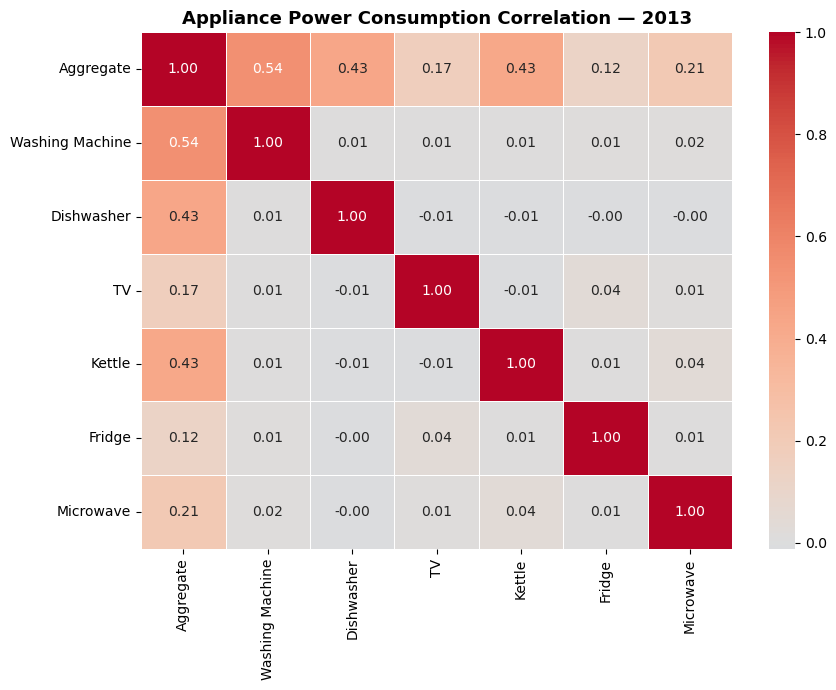

In [11]:
# Correlation between appliances
correlation = df_combined.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Appliance Power Consumption Correlation — 2013", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 11 - Missing Data Visualization

<Figure size 1200x500 with 0 Axes>

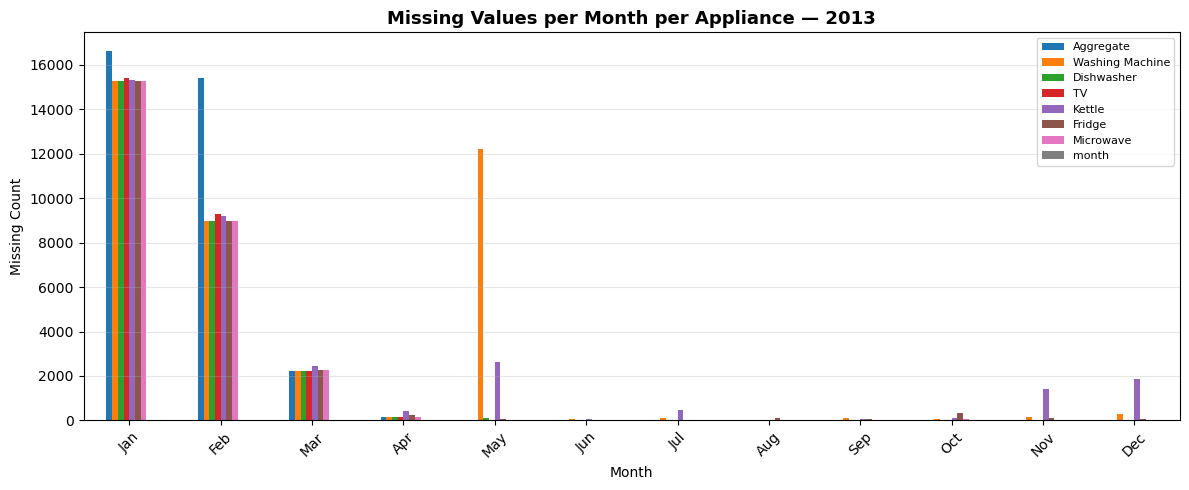

In [12]:
# Missing data per appliance per month
df_missing = df_combined.copy()
df_missing["month"] = df_combined.index.month

monthly_missing = df_missing.isnull().groupby(df_missing.index.month).sum()

plt.figure(figsize=(12, 5))
monthly_missing.plot(kind="bar", figsize=(12, 5))
plt.title("Missing Values per Month per Appliance — 2013", fontsize=13, fontweight="bold")
plt.xlabel("Month", fontsize=10)
plt.ylabel("Missing Count", fontsize=10)
plt.xticks(
    ticks=range(12),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"],
    rotation=45
)
plt.legend(loc="upper right", fontsize=8)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# 12 - Appliance Activity Detection (On/Off State)

In [13]:
# Threshold — 5W se kam ko OFF (0) treat karo
THRESHOLD = 5

df_activity = (df_combined > THRESHOLD).astype(int)

# Activity rate per appliance — kitne % time ON tha
activity_rate = (df_activity.sum() / len(df_activity) * 100).round(2)

print("Appliance Activity Rate (% time ON):\n")
for appliance, rate in activity_rate.items():
    print(f"{appliance:20s} → {rate:6.2f}%")

Appliance Activity Rate (% time ON):

Aggregate            →  93.45%
Washing Machine      →   4.81%
Dishwasher           →   2.20%
TV                   →   9.22%
Kettle               →   0.84%
Fridge               →  41.07%
Microwave            →   0.65%


# 13 - Fridge Power Distribution

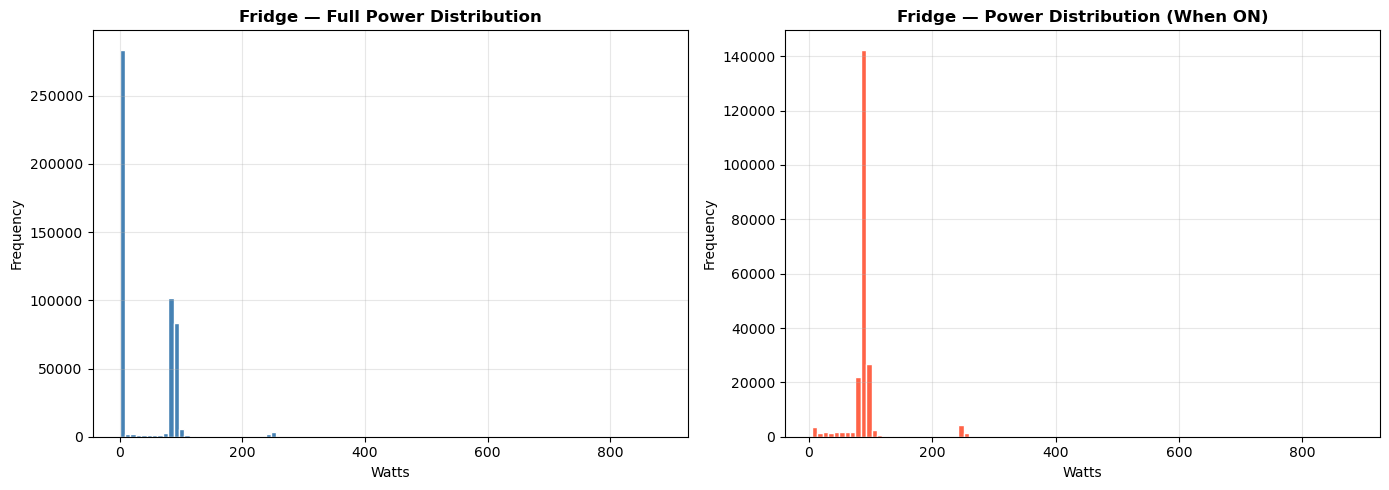

In [14]:
fridge = df_combined["Fridge"].dropna()
fridge_on = fridge[fridge > THRESHOLD]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(fridge.values, bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Fridge — Full Power Distribution", fontweight="bold")
axes[0].set_xlabel("Watts")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

# Only when ON
axes[1].hist(fridge_on.values, bins=100, color="tomato", edgecolor="white")
axes[1].set_title("Fridge — Power Distribution (When ON)", fontweight="bold")
axes[1].set_xlabel("Watts")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 14 - EDA Summary & Key Findings

In [16]:
print("=" * 60)
print("EDA SUMMARY — Energy Sentinel (UK-DALE House 1, 2013)")
print("=" * 60)

print(f"""
DATASET
-------
Date Range     : 2013-01-01 → 2013-12-31
Total Records  : {len(df_combined):,}
Appliances     : {len(df_combined.columns)}
Resolution     : 1-minute (resampled from 6-second)

MISSING DATA
------------
Aggregate       : {df_combined['Aggregate'].isnull().sum():,} ({df_combined['Aggregate'].isnull().mean()*100:.2f}%)
Washing Machine : {df_combined['Washing Machine'].isnull().sum():,} ({df_combined['Washing Machine'].isnull().mean()*100:.2f}%)
Dishwasher      : {df_combined['Dishwasher'].isnull().sum():,} ({df_combined['Dishwasher'].isnull().mean()*100:.2f}%)
TV              : {df_combined['TV'].isnull().sum():,} ({df_combined['TV'].isnull().mean()*100:.2f}%)
Kettle          : {df_combined['Kettle'].isnull().sum():,} ({df_combined['Kettle'].isnull().mean()*100:.2f}%)
Fridge          : {df_combined['Fridge'].isnull().sum():,} ({df_combined['Fridge'].isnull().mean()*100:.2f}%)
Microwave       : {df_combined['Microwave'].isnull().sum():,} ({df_combined['Microwave'].isnull().mean()*100:.2f}%)

ACTIVITY RATES (% time ON, threshold = 5W)
-------------------------------------------
Aggregate       : 93.45%
Washing Machine :  4.81%
Dishwasher      :  2.20%
TV              :  9.22%
Kettle          :  0.84%
Fridge          : 41.07%
Microwave       :  0.65%

KEY FINDINGS
------------
1. Strong seasonal pattern — winter consumption higher than summer
2. Fridge consumption increases in summer (thermal load)
3. Clear daily usage peaks — Kettle at 7AM, Aggregate/TV at 8PM
4. Weekday vs Weekend patterns differ across appliances
5. Most appliances OFF majority of time (sparse activation)
6. 1W baseline noise present — threshold of 5W needed
7. Missing data 5-7% — gaps from sensor/logger interruptions
""")

print("=" * 60)
print("EDA COMPLETE — Ready for Preprocessing")
print("=" * 60)

EDA SUMMARY — Energy Sentinel (UK-DALE House 1, 2013)

DATASET
-------
Date Range     : 2013-01-01 → 2013-12-31
Total Records  : 525,600
Appliances     : 7
Resolution     : 1-minute (resampled from 6-second)

MISSING DATA
------------
Aggregate       : 34,411 (6.55%)
Washing Machine : 39,567 (7.53%)
Dishwasher      : 26,777 (5.09%)
TV              : 27,046 (5.15%)
Kettle          : 34,036 (6.48%)
Fridge          : 27,545 (5.24%)
Microwave       : 26,791 (5.10%)

ACTIVITY RATES (% time ON, threshold = 5W)
-------------------------------------------
Aggregate       : 93.45%
Washing Machine :  4.81%
Dishwasher      :  2.20%
TV              :  9.22%
Kettle          :  0.84%
Fridge          : 41.07%
Microwave       :  0.65%

KEY FINDINGS
------------
1. Strong seasonal pattern — winter consumption higher than summer
2. Fridge consumption increases in summer (thermal load)
3. Clear daily usage peaks — Kettle at 7AM, Aggregate/TV at 8PM
4. Weekday vs Weekend patterns differ across appliances
